# WTI MM Long — Daily COT Nowcasting with Kalman Filter

Estimate daily Managed-Money Long positioning using a Kalman Filter.

- **State**: latent daily positioning level, driven by daily market features
- **Observation**: actual COT level, observed only on Fridays (release date)
- **Train**: first 4 years — **Test**: following 3 years

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.statespace.mlemodel import MLEModel

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load data

In [2]:
from src.utils.io.read import PreprocessedDataReader
from src.preprocessing.base import FutureTicker
from src.settings import Settings

pdr = PreprocessedDataReader(Settings.historical.paths.PREPROCESSED_DATA_PATH)
df = pdr.read_daily_dataset(ticker=FutureTicker.WTI)
df['tradeDate'] = pd.to_datetime(df['tradeDate'])
df.sort_values('tradeDate', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
print(f'Range: {df["tradeDate"].min().date()} -> {df["tradeDate"].max().date()}')
print(f'Fridays with COT: {df["cot_obs_ManagedMoney_LongPosition"].notna().sum()}')

Shape: (3921, 42)
Range: 2010-01-04 -> 2025-08-05
Fridays with COT: 787


## 2. Prepare observation and features

In [3]:
TARGET = 'cot_obs_ManagedMoney_LongPosition'

FEATURES = [
    'F1_RolledPrice_daily_return',
    'F1MinusF2_RolledPrice_daily_return',
    'F1_RolledPrice_rolling_20D_volatility',
    'F1_OI_daily_change',
    'AGG_OI_daily_change',
    'F1_Volume',
    'SyntheticSpread_daily_change',
]

mask = df[FEATURES].notna().all(axis=1)
df = df[mask].reset_index(drop=True)

dates = df['tradeDate'].values
y = df[TARGET].values.astype(float)
X = df[FEATURES].values.astype(float)

print(f'Clean rows: {len(df)}, Friday obs: {np.sum(~np.isnan(y))}')

Clean rows: 3894, Friday obs: 781


## 3. Train / test split

In [4]:
TRAIN_END = '2014-12-31'
TEST_END  = '2017-12-31'

train_mask = df['tradeDate'] <= TRAIN_END
test_mask  = (df['tradeDate'] > TRAIN_END) & (df['tradeDate'] <= TEST_END)

train_idx = np.where(train_mask)[0]
test_idx  = np.where(test_mask)[0]
full_idx  = np.where(df['tradeDate'] <= TEST_END)[0]

n_train_fri = np.sum(~np.isnan(y[train_mask]))
n_test_fri  = np.sum(~np.isnan(y[test_mask]))

print(f'Train: {pd.Timestamp(dates[train_idx[0]]).date()} -> '
      f'{pd.Timestamp(dates[train_idx[-1]]).date()}  '
      f'({len(train_idx)} days, {n_train_fri} Friday obs)')
print(f'Test:  {pd.Timestamp(dates[test_idx[0]]).date()} -> '
      f'{pd.Timestamp(dates[test_idx[-1]]).date()}  '
      f'({len(test_idx)} days, {n_test_fri} Friday obs)')

Train: 2010-02-02 -> 2014-12-31  (1236 days, 248 Friday obs)
Test:  2015-01-02 -> 2017-12-29  (755 days, 151 Friday obs)


## 4. Standardise using train statistics only

In [5]:
X_mean = np.nanmean(X[train_idx], axis=0)
X_std  = np.nanstd(X[train_idx], axis=0) + 1e-8
X_scaled = (X - X_mean) / X_std

y_train_obs = y[train_idx][~np.isnan(y[train_idx])]
y_mean = y_train_obs.mean()
y_std  = y_train_obs.std() + 1e-8
y_scaled = (y - y_mean) / y_std

print(f'y (MM Long level) -- mean: {y_mean:,.0f}  std: {y_std:,.0f}')

y (MM Long level) -- mean: 448,388  std: 88,504


## 5. Kalman Filter model

```
State:        a_t = a_{t-1} + B . x_t + eta_t     (daily features drive state)
Observation:  y_t = a_t + eps_t                     (Fridays only)
```

In [6]:
class DailyKF(MLEModel):

    def __init__(self, endog, exog):
        self.p_ = exog.shape[1]
        super().__init__(endog, k_states=1, k_posdef=1)
        self['design', 0, 0]     = 1.0
        self['transition', 0, 0] = 1.0
        self['selection', 0, 0]  = 1.0
        self._exog = np.array(exog)
        self.initialize_approximate_diffuse()

    @property
    def param_names(self):
        return ['log_h', 'log_q'] + [f'B_{j}' for j in range(self.p_)]

    @property
    def start_params(self):
        obs_valid = self.endog[~np.isnan(self.endog[:, 0])]
        log_std = np.log(np.std(obs_valid) + 1e-6)
        return np.concatenate([[log_std, log_std - 1.0], np.zeros(self.p_)])

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self['obs_cov', 0, 0]   = np.exp(params[0]) ** 2
        self['state_cov', 0, 0] = np.exp(params[1]) ** 2
        B = params[2:].reshape(1, self.p_)
        self['state_intercept'] = B @ self._exog.T

## 6. Fit on train, filter over train+test

In [7]:
mod_train = DailyKF(y_scaled[train_idx].reshape(-1, 1), X_scaled[train_idx])
res_train = mod_train.fit(disp=False, method='lbfgs', maxiter=500)
print(f'Train LogLik: {res_train.llf:.2f}  AIC: {res_train.aic:.2f}')
print(f'Params: {dict(zip(res_train.param_names, res_train.params.round(4)))}')

Train LogLik: 75.92  AIC: -133.84
Params: {'log_h': np.float64(-2.6574), 'log_q': np.float64(-2.7374), 'B_0': np.float64(0.0247), 'B_1': np.float64(-0.001), 'B_2': np.float64(-0.0008), 'B_3': np.float64(-0.0056), 'B_4': np.float64(0.0179), 'B_5': np.float64(-0.0046), 'B_6': np.float64(0.0046)}


In [8]:
# Run filter over train+test with train-fitted params
mod_full = DailyKF(y_scaled[full_idx].reshape(-1, 1), X_scaled[full_idx])
res_full = mod_full.filter(res_train.params)

filtered_state = res_full.filtered_state[0] * y_std + y_mean
filtered_std   = np.sqrt(res_full.filtered_state_cov[0, 0, :]) * y_std

dates_full = dates[full_idx]
y_full     = y[full_idx]

print(f'Filtered range: {filtered_state.min():,.0f} -> {filtered_state.max():,.0f}')

Filtered range: 275,437 -> 874,483


## 7. Visualise: estimated vs actual

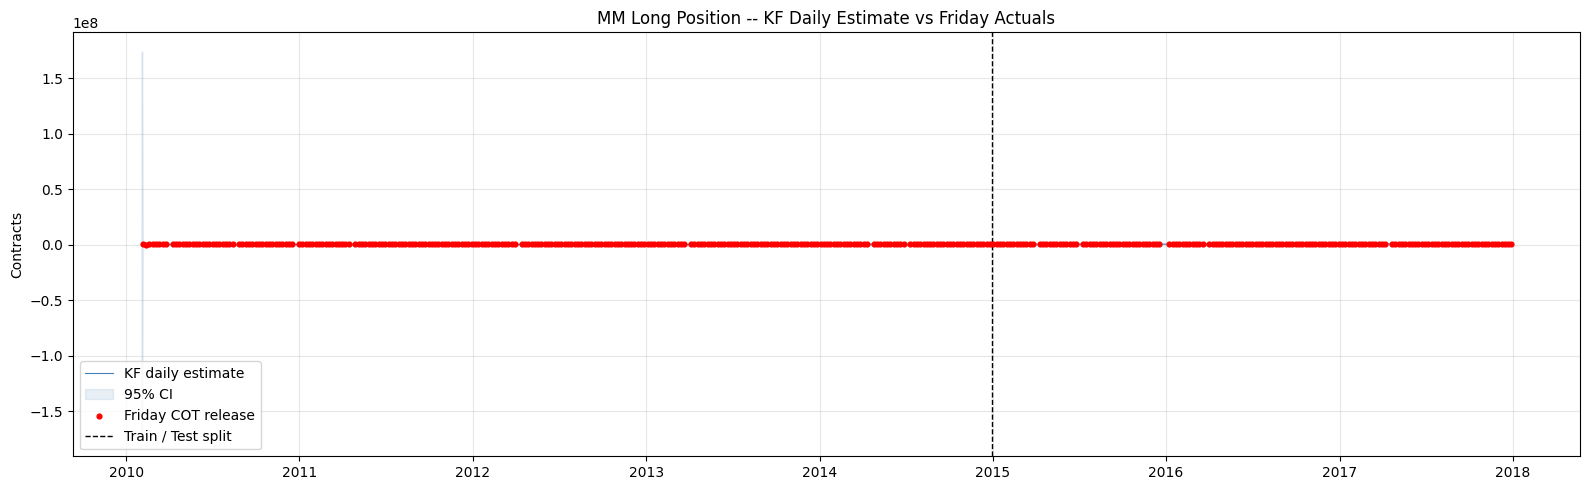

In [9]:
obs_mask = ~np.isnan(y_full)
train_end_dt = np.datetime64(TRAIN_END)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_full, filtered_state,
        color='steelblue', linewidth=0.8, label='KF daily estimate')
ax.fill_between(dates_full,
                filtered_state - 1.96 * filtered_std,
                filtered_state + 1.96 * filtered_std,
                alpha=0.12, color='steelblue', label='95% CI')
ax.scatter(dates_full[obs_mask], y_full[obs_mask],
           color='red', s=12, zorder=5, label='Friday COT release')
ax.axvline(train_end_dt, color='black', linestyle='--', linewidth=1,
           label='Train / Test split')
ax.set_title('MM Long Position -- KF Daily Estimate vs Friday Actuals')
ax.set_ylabel('Contracts')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

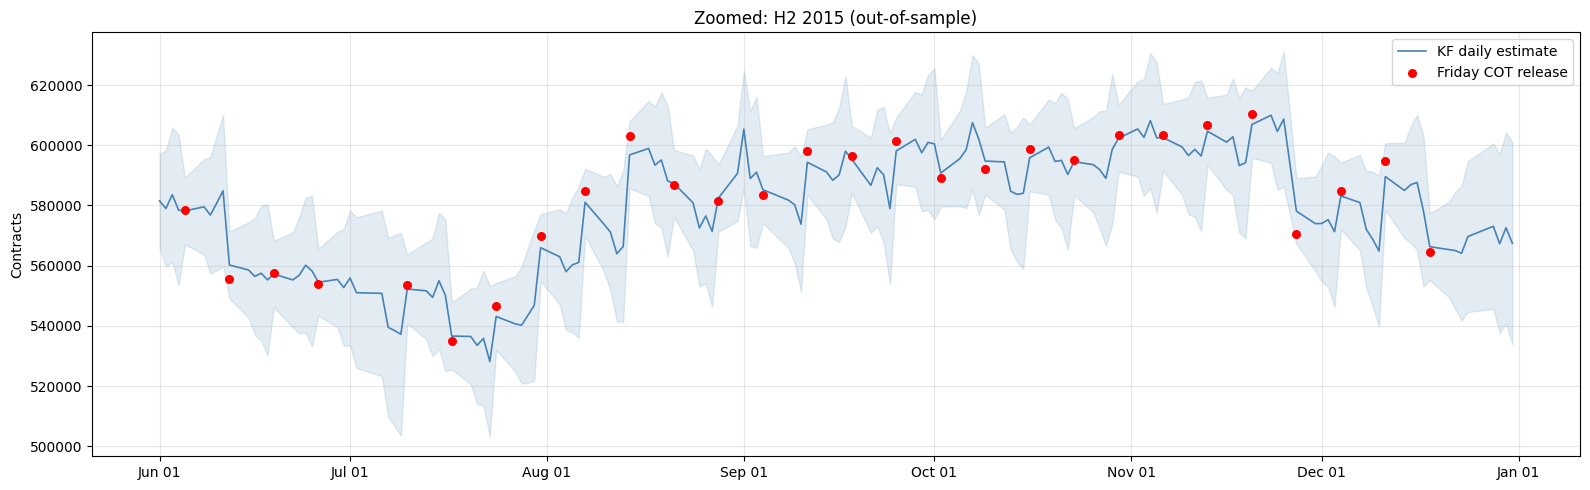

In [10]:
zoom_start = np.datetime64('2015-06-01')
zoom_end   = np.datetime64('2015-12-31')
zm = (dates_full >= zoom_start) & (dates_full <= zoom_end)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_full[zm], filtered_state[zm],
        color='steelblue', linewidth=1.2, label='KF daily estimate')
ax.fill_between(dates_full[zm],
                (filtered_state - 1.96 * filtered_std)[zm],
                (filtered_state + 1.96 * filtered_std)[zm],
                alpha=0.15, color='steelblue')
obs_zm = zm & obs_mask
ax.scatter(dates_full[obs_zm], y_full[obs_zm],
           color='red', s=30, zorder=5, label='Friday COT release')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_title('Zoomed: H2 2015 (out-of-sample)')
ax.set_ylabel('Contracts')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Test-period metrics (week-over-week changes)

In [11]:
# Evaluate on weekly CHANGES, not levels.
# Levels are highly autocorrelated so Spearman on levels is misleading.
# The real test: does the KF predict the direction/magnitude of the
# week-over-week positioning shift?

test_fri = (dates_full > np.datetime64(TRAIN_END)) & obs_mask
fri_idx  = np.where(test_fri)[0]

pred_level  = filtered_state[fri_idx]
actual_level = y_full[fri_idx]

# Week-over-week change: this Friday vs last Friday
pred_change   = np.diff(pred_level)
actual_change = np.diff(actual_level)

rho, _ = stats.spearmanr(pred_change, actual_change)
rmse   = np.sqrt(np.mean((pred_change - actual_change) ** 2))
mae    = np.mean(np.abs(pred_change - actual_change))
dir_acc = np.mean(np.sign(pred_change) == np.sign(actual_change))

print(f'Test Fridays (changes): {len(pred_change)}')
print(f'Spearman rho:   {rho:.4f}')
print(f'Dir. accuracy:  {dir_acc:.1%}')
print(f'RMSE:           {rmse:,.0f} contracts')
print(f'MAE:            {mae:,.0f} contracts')


Test Fridays (changes): 150
Spearman rho:   0.9648
Dir. accuracy:  93.3%
RMSE:           4,748 contracts
MAE:            3,528 contracts


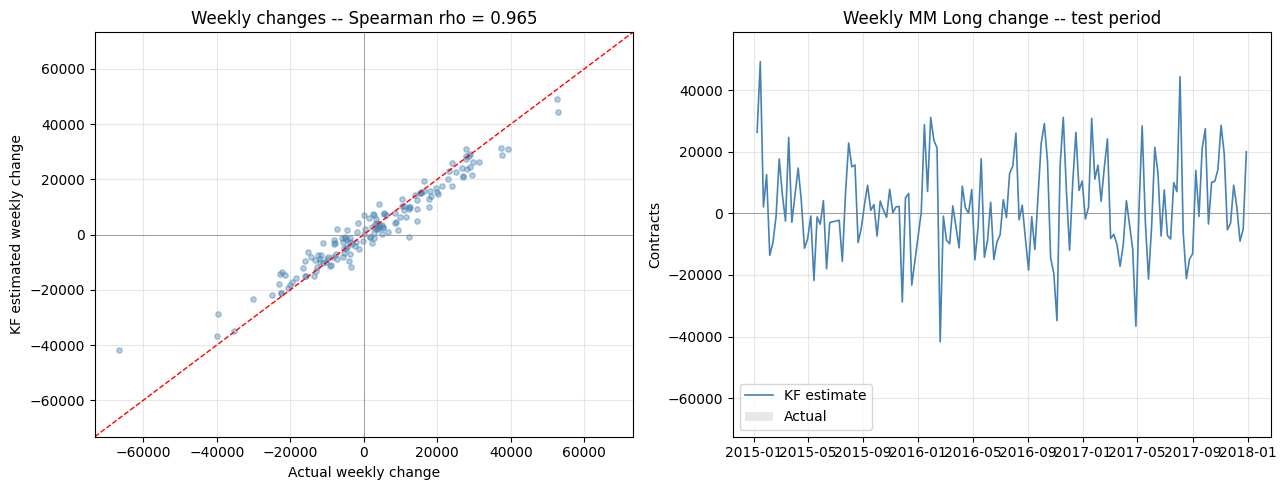

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter of weekly changes
ax = axes[0]
ax.scatter(actual_change, pred_change, alpha=0.4, s=15, color='steelblue')
lim = max(np.abs(actual_change).max(), np.abs(pred_change).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('Actual weekly change')
ax.set_ylabel('KF estimated weekly change')
ax.set_title(f'Weekly changes -- Spearman rho = {rho:.3f}')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)

# Right: time series of changes
ax = axes[1]
fri_dates = dates_full[fri_idx][1:]  # skip first (no prior for diff)
ax.bar(fri_dates, actual_change, width=5, alpha=0.5, color='lightgrey', label='Actual')
ax.plot(fri_dates, pred_change, color='steelblue', linewidth=1.2, label='KF estimate')
ax.axhline(0, color='grey', lw=0.5)
ax.set_title('Weekly MM Long change -- test period')
ax.set_ylabel('Contracts')
ax.legend()

plt.tight_layout()
plt.show()
